 Demo UQU Chatbot Assistant

In [1]:
import json
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout,GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from langdetect import detect

In [2]:
from tensorflow.keras.callbacks import EarlyStopping


In [3]:
file_path = "chatbot input.json"
with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)

In [4]:

# Extract patterns and responses
patterns = []
labels = []
responses_dict = {}

for intent in data["intents"]:
    for pattern in intent["patterns"]:
        patterns.append(pattern)
        labels.append(intent["tag"])
    responses_dict[intent["tag"]] = intent["responses"]

# Tokenize the input text
tokenizer = Tokenizer()
tokenizer.fit_on_texts(patterns)
vocab_size = len(tokenizer.word_index) + 1

# Convert text to sequences
sequences = tokenizer.texts_to_sequences(patterns)
max_length = max(len(seq) for seq in sequences)
X = pad_sequences(sequences, maxlen=max_length, padding="post")



In [5]:

# Encode labels as integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
y = tf.keras.utils.to_categorical(y, num_classes=len(label_encoder.classes_))

LSTM Model

In [6]:

# Build LSTM model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(128, return_sequences=True),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(len(label_encoder.classes_), activation="softmax")
])
# Compile the model
model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Train the model
train =model.fit(X, y, epochs=35, batch_size=8, verbose=1)

c:\Users\aymna\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.2015 - loss: 2.4670
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1274 - loss: 2.2879 
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.1674 - loss: 2.1686 
Epoch 4/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3736 - loss: 1.7244
Epoch 5/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4549 - loss: 1.6145
Epoch 6/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3560 - loss: 1.7143
Epoch 7/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3433 - loss: 1.6402
Epoch 8/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3532 - loss: 1.6733
Epoch 9/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4422 - loss: 1.5298
Epoch 10/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4262 - loss: 1.4240
Epoch 11/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5281 - loss: 1.2104
Epoch 12/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accurac

In [7]:

# Save the model and tokenizers
model.save("chatbot_lstm.h5")

# Save tokenizer and label encoder mappings
import pickle
with open("tokenizer.pickle", "wb") as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
with open("label_encoder.pickle", "wb") as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)


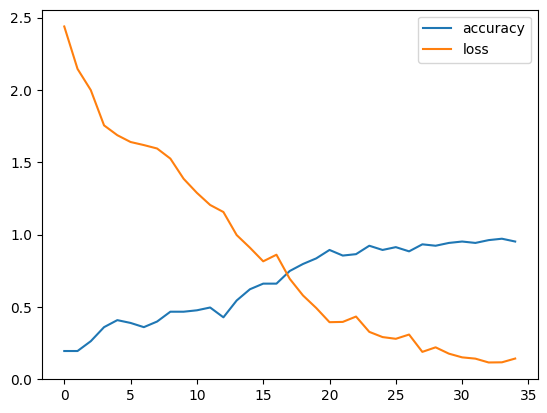

In [8]:
plt.plot(train.history['accuracy'],label='accuracy')
plt.plot(train.history['loss'],label='loss')
plt.legend()

In [16]:

# Define function to get chatbot response
def chatbot_response(text):
    with open("tokenizer.pickle", "rb") as handle:
        tokenizer = pickle.load(handle)
    with open("label_encoder.pickle", "rb") as handle:
        label_encoder = pickle.load(handle)
    
    model = tf.keras.models.load_model("chatbot_lstm.h5")
    
    seq = tokenizer.texts_to_sequences([text])
    padded_seq = pad_sequences(seq, maxlen=max_length, padding="post")
    prediction = model.predict(padded_seq)
    tag_index = np.argmax(prediction)
    predicted_tag = label_encoder.inverse_transform([tag_index])[0]

    if predicted_tag in responses_dict:
        # Detect input language
        if text.isascii():
            response = random.choice(responses_dict[predicted_tag]["en"])
        else:
            response = random.choice(responses_dict[predicted_tag]["ar"])
        return response
    else:
        return "I'm sorry, I don't understand."

# Interactive chat loop
print("Chatbot is ready! Type 'exit' to stop.")
while True:
    user_input = input("You: ")
    if user_input.lower() == "exit":
        print("Chatbot: Goodbye!")
        break
    response = chatbot_response(user_input)
    print(f"Chatbot: {response}")

Chatbot is ready! Type 'exit' to stop.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 835ms/step
Chatbot: Hey! How can I help?


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 717ms/step
Chatbot: بعد القبول في جامعة أم القرى، يجب عليك: 1. الحصول على رقمك الجامعي من خلال حسابك في بوابة القبول الموحد. 2. سيتم تفعيل حسابك في البوابة الأكاديمية وتسجيل جدولك الدراسي تلقائيًا. 3. متابعة بريدك الإلكتروني الجامعي بانتظام للتواصل الرسمي. 4. إذا رغبت في إلغاء قبولك، يمكنك ذلك إلكترونيًا عبر بوابة القبول الموحد.
Chatbot: Goodbye!


GRU model

In [10]:

# Define GRU model
model = Sequential([
    Embedding(input_dim=len(tokenizer.word_index) + 1, output_dim=128, input_length=max_length),
    GRU(128, return_sequences=True),
    Dropout(0.2),
    GRU(128),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(label_encoder.classes_), activation='softmax')
])

In [11]:

# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [12]:

# Train model
Train = model.fit(X, y, epochs=35, batch_size=8, verbose=1)


Epoch 1/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.1180 - loss: 2.4665
Epoch 2/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2611 - loss: 2.2921
Epoch 3/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.2451 - loss: 2.1946
Epoch 4/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.2854 - loss: 1.9047
Epoch 5/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2919 - loss: 1.8911
Epoch 6/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4182 - loss: 1.6787
Epoch 7/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3777 - loss: 1.6489
Epoch 8/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3694 - loss: 1.6397
Epoch 9/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3700 - loss: 1.6467
Epoch 10/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3956 - loss: 1.5443
Epoch 11/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4908 - loss: 1.2976
Epoch 12/35
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy

In [13]:

# Save the trained model and preprocessing tools
model.save("chatbot_gru_model.h5")

# Save tokenizer and label encoder
tokenizer_json = tokenizer.to_json()
with open("tokenizer.json", "w", encoding='utf-8') as f:
    json.dump(tokenizer_json, f, ensure_ascii=False)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("GRU model training completed and saved successfully!")

GRU model training completed and saved successfully!


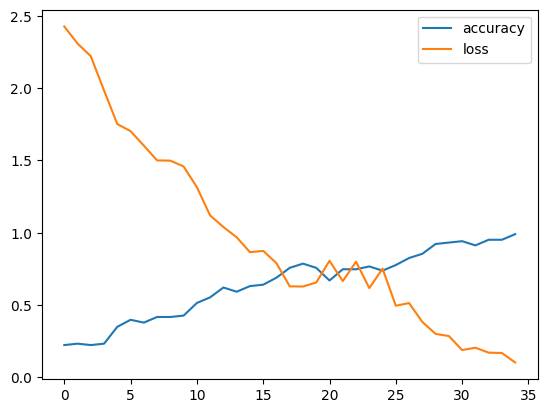

In [14]:
plt.plot(Train.history['accuracy'],label='accuracy')
plt.plot(Train.history['loss'],label='loss')
plt.legend()

In [15]:

responses_dict = {intent['tag']: intent['responses'] for intent in data['intents']}

# Load tokenizer and label encoder
with open("tokenizer.pickle", "rb") as handle:
    tokenizer = pickle.load(handle)

with open("label_encoder.pickle", "rb") as handle:
    label_encoder = pickle.load(handle)

# Load trained GRU model
model = tf.keras.models.load_model("chatbot_gru_model.h5")

# Define max sequence length (same as used during training)
max_length = model.input_shape[1]

# Define function to get chatbot response
def chatbot_response(text):
    seq = tokenizer.texts_to_sequences([text])
    padded_seq = pad_sequences(seq, maxlen=max_length, padding="post")
    prediction = model.predict(padded_seq)
    
    tag_index = np.argmax(prediction)
    predicted_tag = label_encoder.inverse_transform([tag_index])[0]

    if predicted_tag in responses_dict:
        # Detect input language
        lang = "ar" if detect(text) == "ar" else "en"
        response = random.choice(responses_dict[predicted_tag][lang])
        return response
    else:
        return "I'm sorry, I don't understand."

# Interactive chat loop
print("Chatbot is ready! Type 'exit' to stop.")
while True:
    user_input = input("You: ")
    if user_input.lower() in ["exit", "quit", "خروج"]:
        print("Chatbot: Goodbye! مع السلامة!")
        break
    response = chatbot_response(user_input)
    print(f"Chatbot: {response}")


Chatbot is ready! Type 'exit' to stop.
Chatbot: Goodbye! مع السلامة!
